![root](images/roots.png)
![root](images/roots1.png)

# Here we will solve quadratic equation using AI workflow.

In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Literal

In [3]:
class qdstate(TypedDict):

    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [14]:
def show_eq(state:qdstate):
    a = state['a']
    b = state['b']
    c = state['c']

    eq = f"{a}*X^2 + {b}*X + {c}"


    return {'equation': eq}

def cal_discriminant(state:qdstate):

    dist = state["b"]**2 - (4 * state['a']* state['c']
)
    return {"discriminant": dist}

def real_root(state:qdstate):

    root1 =  (-state["b"] + state["discriminant"]**0.5)/( 2* state['a'])
    root2 = (-state["b"] - state["discriminant"]**0.5)/( 2* state['a'])

    result = f"The roots are {root1} and {root2}"

    return {"result":result}

def repeated_roots(state:qdstate):

    root1 =  (-state["b"])/( 2* state['a'])

    result = f"The only repeating roots are {root1}"

    return {"result":result}


def no_real_roots(state:qdstate):


    result = f"No real roots"

    return {"result":result}

In [15]:

# Routing function -------------------

def check_condition(state:qdstate) -> Literal["real_root","repeated_roots","no_real_roots"]:

    if state["discriminant"]> 0:
        return "real_root"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

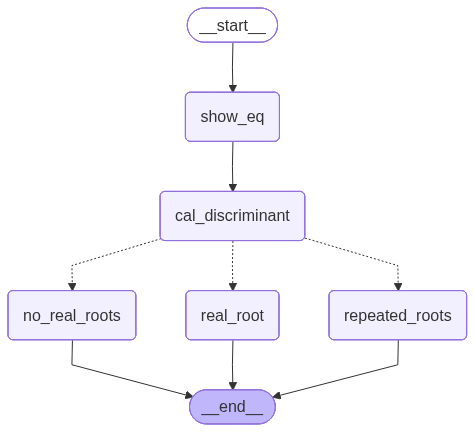

In [17]:
graph = StateGraph(qdstate)

graph.add_node("show_eq", show_eq)
graph.add_node("cal_discriminant", cal_discriminant)
graph.add_node("real_root", real_root)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("no_real_roots", no_real_roots)


graph.add_edge(START, "show_eq")
graph.add_edge("show_eq","cal_discriminant")

graph.add_conditional_edges("cal_discriminant",check_condition)
graph.add_edge("real_root", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)


workflow = graph.compile()

workflow


In [18]:
init_state = {
    "a": 2,
    "b": 4,
    "c": 5
}

In [19]:
workflow.invoke(init_state)

{'a': 2,
 'b': 4,
 'c': 5,
 'equation': '2*X^2 + 4*X + 5',
 'discriminant': -24,
 'result': 'No real roots'}